In [1]:
# ============================================
# Audience Reception and Production Patterns in Danish Cinema
# ============================================

# Context
# Film is an important cultural and creative industry that reflects the artistic
# and historical identity of a society. Denmark has one of the oldest film
# industries in the world, with production dating back to the late 19th century.
# Differences in audience reception of films can reflect broader patterns in
# production quality, genre preferences, and industry structure. Previous studies
# suggest that factors such as era of production, genre, runtime, and production
# company may influence how audiences receive and engage with films. Understanding
# these patterns can help filmmakers, cultural institutions, and policymakers make
# informed decisions about film production, funding, and preservation.

# Problem Statement
# This project investigates whether era of production, genre, runtime, and
# production company influence audience ratings of Danish films. Using data from
# The Movie Database (TMDB), the analysis focuses on Danish films spanning from
# the late 1800s to the present and explores how audience ratings and engagement
# differ across these dimensions. Business Intelligence techniques and machine
# learning methods will be used to analyse patterns in the data and examine
# whether audience reception can be predicted based on film characteristics.

# Research Questions
# RQ1 - Does the era of production influence the average audience rating of Danish films?
# RQ2 - Do genre and runtime influence the audience rating of Danish films?
# RQ3 - Can audience ratings be predicted using film characteristics such as genre,
#        runtime, and production company?

# Hypotheses
# H1 - Films released after 1950 will have higher average ratings than earlier films,
#      reflecting improved production quality and more reliable rating data.
# H2 - Drama and documentary genres will receive higher average ratings than action
#      or comedy genres in the Danish context.
# H3 - Films with a runtime between 90 and 120 minutes will receive higher average
#      ratings than very short or very long films.
# H4 - A small number of production companies will account for the majority of highly
#      rated films, suggesting concentration of quality production.

# Dataset
# The dataset used in this project comes from The Movie Database (TMDB),
# specifically a curated collection of Danish films. The dataset includes metadata
# for over 5,000 Danish films spanning from 1897 to the present. Key variables
# include release date, genre, runtime, vote average, vote count, popularity, and
# production company. Films were filtered to include only Danish origin productions
# and a minimum vote count threshold was applied to ensure rating reliability.

# BI Relevance
# Business Intelligence techniques will be used to analyse and visualise patterns
# in audience reception across different film characteristics. By exploring
# relationships between era, genre, runtime, and production company, the analysis
# can reveal potential drivers of film quality and audience engagement. These
# insights may support data-driven decisions about film production strategies,
# cultural funding priorities, and the preservation of Danish cinema heritage.

# Project Plan
# Stage 1 - Problem formulation
# Stage 2 - Data preparation and EDA
# Stage 3 - Machine learning modelling
# Stage 4 - Deployment and visualisation

SyntaxError: invalid decimal literal (3103351673.py, line 9)

In [ ]:
!pip list

In [47]:
!pip install pgeocode

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [48]:
!pip install -U folium

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [49]:
!python -m pip install -U folium

The system cannot find the file C:\Users\khnda\AppData\Local\Microsoft\WindowsApps\python.exe.


In [50]:
!pip install -U pandas

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [51]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from typing import List

In [54]:
pd.__version__

'3.0.1'

In [55]:
pd.set_option('display.float_format', lambda x: '%.6f' % x)

In [56]:
# ============================================
# TASK 1 - DATA LOADING
# ============================================

In [57]:
df = pd.read_csv('data/danish_movies.csv')

In [58]:
df.shape

(5134, 30)

In [59]:
df.columns

Index(['adult', 'backdrop_path', 'budget', 'homepage', 'id', 'imdb_id',
       'origin_country', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'video', 'vote_average', 'vote_count', 'genre_ids',
       'production_company_ids', 'collection_id', 'cast_person_ids',
       'cast_credit_ids', 'crew_person_ids', 'crew_credit_ids'],
      dtype='str')

In [60]:
df.dtypes

adult                        bool
backdrop_path                 str
budget                      int64
homepage                      str
id                          int64
imdb_id                       str
origin_country                str
original_language             str
original_title                str
overview                      str
popularity                float64
poster_path                   str
production_countries          str
release_date                  str
revenue                     int64
runtime                     int64
spoken_languages              str
status                        str
tagline                       str
title                         str
video                        bool
vote_average              float64
vote_count                  int64
genre_ids                     str
production_company_ids        str
collection_id             float64
cast_person_ids               str
cast_credit_ids               str
crew_person_ids               str
crew_credit_id

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5134 entries, 0 to 5133
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   adult                   5134 non-null   bool   
 1   backdrop_path           1959 non-null   str    
 2   budget                  5134 non-null   int64  
 3   homepage                245 non-null    str    
 4   id                      5134 non-null   int64  
 5   imdb_id                 3689 non-null   str    
 6   origin_country          5134 non-null   str    
 7   original_language       5134 non-null   str    
 8   original_title          5134 non-null   str    
 9   overview                3895 non-null   str    
 10  popularity              5134 non-null   float64
 11  poster_path             4089 non-null   str    
 12  production_countries    5134 non-null   str    
 13  release_date            5134 non-null   str    
 14  revenue                 5134 non-null   int64  
 15

In [62]:
df.sample(5)

,adult,backdrop_path,budget,homepage,id,imdb_id,origin_country,original_language,original_title,overview,...,video,vote_average,vote_count,genre_ids,production_company_ids,collection_id,cast_person_ids,cast_credit_ids,crew_person_ids,crew_credit_ids
1996,False,/vc4dReSMJ02cJwLBZodzUZN15NF.jpg,0,NaN,232201,tt0126086,['DK'],da,Sunes familie,"It's vacation time, but the Andersen family ca...",...,False,5.800000,4,"[10751, 35]","[3675, 118]",NaN,"[202573, 202575, 84244, 1267481, 1267482, 1267...","['52fe4dffc3a36847f82787f9', '52fe4dffc3a36847...","[1077290, 1018020, 1097234, 558214, 1018020, 1...","['611be6a03a4a12002f4a3d36', '5b5ccd0692514152..."
477,False,NaN,0,NaN,1210524,NaN,['DK'],da,Klarinetspilleren,FRAGMENT | A man looks around and sees a dog i...,...,False,0.000000,0,[],[],NaN,[],[],[1272275],['656493247dfda6592f54838c']
438,False,NaN,0,NaN,298617,tt2239704,['DK'],da,Lykken,"Peter Niemand, a blacksmith by trade, is prone...",...,False,0.000000,0,[18],[235],NaN,"[1376535, 1268911, 1268656, 1174479, 1268908, ...","['5447b98ac3a3686d84002782', '5447b9960e0a2611...","[29034, 29029, 2411855, 1665787]","['613ffde65e120000422c59d7', '5447b9660e0a2672..."
4467,False,/xFCIBxV4IYPIjgtfeb23Tjk2af2.jpg,13424,NaN,875180,tt13073398,['DK'],da,Hellige Høne,An old religious married couple discovers some...,...,False,0.000000,0,[35],[],NaN,"[111599, 1119438, 43873, 558080, 2185273]","['6144a7575e12000020b1ef5b', '6144a76767203d00...","[1542778, 1542778, 3237999, 1299307, 3238003, ...","['6144a7fc9450fe0064f6aa08', '6144a7f09f0e1900..."
3656,False,NaN,0,NaN,710202,tt6037022,['DK'],da,Alice,"Alice is a singer in a traveling circus, where...",...,False,0.000000,0,[],[],NaN,"[2659060, 2659062, 2659063]","['5ed11234528b2e001e676feb', '5ed1124396386400...","[2659059, 2659059]","['5ed1122698f1f1001decfa0b', '5ed1122c5c071b00..."


In [63]:
df.isna().sum()

adult                        0
backdrop_path             3175
budget                       0
homepage                  4889
id                           0
imdb_id                   1445
origin_country               0
original_language            0
original_title               0
overview                  1239
popularity                   0
poster_path               1045
production_countries         0
release_date                 0
revenue                      0
runtime                      0
spoken_languages             0
status                       0
tagline                   4825
title                        0
video                        0
vote_average                 0
vote_count                   0
genre_ids                    0
production_company_ids       0
collection_id             4871
cast_person_ids              0
cast_credit_ids              0
crew_person_ids              0
crew_credit_ids              0
dtype: int64

In [64]:
# ============================================
# TASK 2 - REMOVING DUPLICATES, NAN AND UNNECESSARY COLUMNS
# ============================================

In [65]:
cols_to_keep = [
    'id', 'title', 'release_date', 'origin_country', 'original_language',
    'runtime', 'vote_average', 'vote_count', 'popularity',
    'genre_ids', 'production_company_ids'
]

df = df[cols_to_keep]

In [66]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')


In [67]:
df.sample(5)

,id,title,release_date,origin_country,original_language,runtime,vote_average,vote_count,popularity,genre_ids,production_company_ids
1548,33942,Girls at Sea,1977-09-16,['DK'],da,100,5.800000,7,3.292300,[35],[4294]
3799,470415,The Stranger,2017-09-14,['DK'],da,100,5.000000,5,0.105600,[99],"[758, 118]"
1227,1177932,B for Block,1967-01-01,['DK'],da,9,0.000000,0,0.053800,[16],"[118, 46509, 154381]"
4004,545569,Sticks and Stones,2018-11-22,['DK'],da,93,6.000000,4,1.491100,[18],"[88231, 118, 12496, 640]"
2517,1517873,Purity Beats Everything,2007-01-01,['DK'],da,0,0.000000,0,0.028600,[],[]


In [68]:
import ast
for col in ['genre_ids', 'production_company_ids']:
    df[col] = df[col].apply(ast.literal_eval)

In [69]:
df.isna().sum()

id                        0
title                     0
release_date              0
origin_country            0
original_language         0
runtime                   0
vote_average              0
vote_count                0
popularity                0
genre_ids                 0
production_company_ids    0
dtype: int64

In [70]:
(df['runtime'] == 0).sum()

np.int64(1842)

In [71]:
(df == 0).sum()

id                           0
title                        0
release_date                 0
origin_country               0
original_language            0
runtime                   1842
vote_average              2518
vote_count                2522
popularity                 314
genre_ids                    0
production_company_ids       0
dtype: int64

In [72]:
df['runtime'] = df['runtime'].replace(0, pd.NA)

In [73]:
(df['runtime'] == 0).sum()

np.int64(0)

In [74]:
df.duplicated(subset='id').sum()

np.int64(0)

In [75]:
df['origin_country'].value_counts()

origin_country
['DK']                                              5023
['DK', 'SE']                                          16
['DK', 'GB']                                          12
['US']                                                10
['DK', 'DE']                                           6
['DK', 'US']                                           4
['DK', 'NO']                                           4
[]                                                     3
['DK', 'IS']                                           3
['DE']                                                 3
['DK', 'CA']                                           3
['DK', 'FR']                                           3
['DK', 'IR']                                           2
['DK', 'NO', 'SE']                                     2
['DK', 'DE', 'SE']                                     2
['IS', 'DK']                                           2
['DK', 'GL']                                           2
['DE', 'DK']    

In [76]:
df = df[df['origin_country'].str.contains('DK')]

In [77]:
df.sample(5)

,id,title,release_date,origin_country,original_language,runtime,vote_average,vote_count,popularity,genre_ids,production_company_ids
4198,1077045,Niels Roos - Manden de kaldte Niarn,2019-12-25,['DK'],da,<NA>,0.000000,0,0.115700,"[35, 10402]",[]
43,232662,Lerfossen,1906-09-08,['DK'],da,1,6.000000,1,0.083900,[99],[]
2269,33294,In Your Hands,2004-01-23,['DK'],da,101,5.900000,16,0.932100,[18],[76]
2911,77501,Max Embarrasing 2,2011-04-07,['DK'],da,93,5.500000,2,0.210000,"[35, 10751]",[49125]
4971,1082942,B.O.Y. - Bruises of Yesterday,2024-04-04,['DK'],da,87,8.300000,7,2.276000,[18],"[240566, 8264, 119, 640, 240567, 150551]"


In [78]:
df['runtime'].isna().sum()

np.int64(1839)

In [79]:
df_runtime = df.dropna(subset=['runtime'])

In [80]:
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')

In [81]:
from scipy import stats

In [82]:
# Pandas built-in correlation
df[['runtime', 'vote_average', 'vote_count', 'popularity']].corr()

,runtime,vote_average,vote_count,popularity
runtime,1.000000,0.466169,0.142276,0.296519
vote_average,0.466169,1.000000,0.124962,0.263295
vote_count,0.142276,0.124962,1.000000,0.226440
popularity,0.296519,0.263295,0.226440,1.000000


In [116]:
df_rated['era'] = df_rated['release_date'].dt.year.apply(lambda x: 'Before 1950' if x < 1950 else 'After 1950')

# Central tendency and dispersion
df_rated.groupby('era')['vote_average'].agg([
    'mean', 'median', 'std', 'var', 'min', 'max', 'count',
    lambda x: x.max() - x.min()  # range
]).rename(columns={'<lambda_0>': 'range'})

,mean,median,std,var,min,max,count,range
era,,,,,,,,
After 1950,5.953863,6.000000,1.023506,1.047565,2.200000,10.000000,935,7.800000
Before 1950,5.877551,6.100000,1.031234,1.063444,3.100000,8.600000,49,5.500000


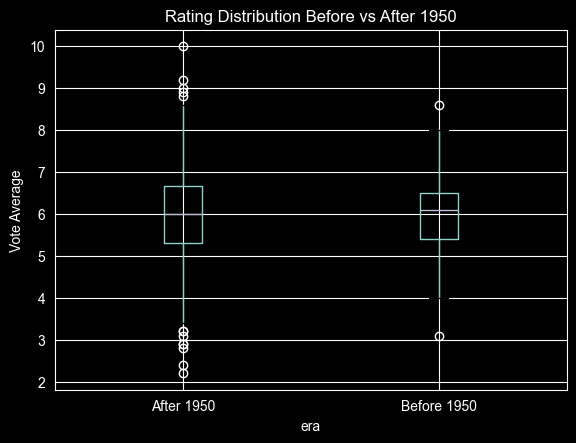

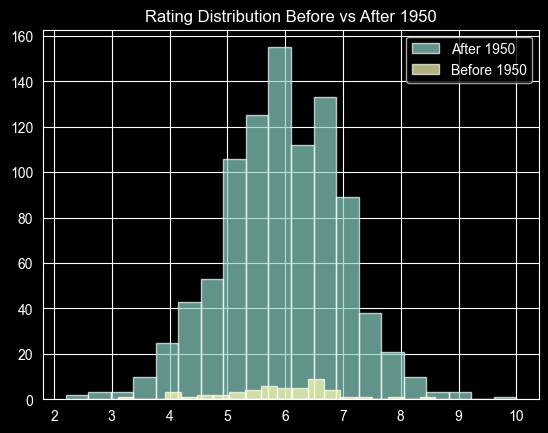

In [117]:
# Box plot
df_rated.boxplot(column='vote_average', by='era')
plt.title('Rating Distribution Before vs After 1950')
plt.suptitle('')
plt.ylabel('Vote Average')
plt.show()

# Histogram
df_rated.groupby('era')['vote_average'].hist(alpha=0.7, bins=20)
plt.legend(['After 1950', 'Before 1950'])
plt.title('Rating Distribution Before vs After 1950')
plt.show()

In [118]:
Q1 = df_rated['vote_average'].quantile(0.25)
Q3 = df_rated['vote_average'].quantile(0.75)
IQR = Q3 - Q1

outliers = df_rated[
    (df_rated['vote_average'] < Q1 - 1.5 * IQR) |
    (df_rated['vote_average'] > Q3 + 1.5 * IQR)
]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Number of outliers: {len(outliers)}")

Q1: 5.3, Q3: 6.62525, IQR: 1.3252500000000005
Number of outliers: 14


In [119]:
# Formal hypothesis definition
print("H0: There is no difference in ratings before and after 1950")
print("Ha: Films after 1950 have higher ratings than before 1950")
print()
print(f"Before 1950 mean: {before_1950.mean():.2f}")
print(f"After 1950 mean: {after_1950.mean():.2f}")
print(f"Mann-Whitney p-value: 0.666")
print()
print("Conclusion: Fail to reject H0 — H1 is rejected")

H0: There is no difference in ratings before and after 1950
Ha: Films after 1950 have higher ratings than before 1950

Before 1950 mean: 5.88
After 1950 mean: 5.95
Mann-Whitney p-value: 0.666

Conclusion: Fail to reject H0 — H1 is rejected


In [84]:
bins = [0, 30, 60, 90, 120, 180, 300]
labels = ['<30', '30-60', '60-90', '90-120', '120-180', '180+']
df_runtime['runtime_group'] = pd.cut(df_runtime['runtime'], bins=bins, labels=labels)
df_runtime.groupby('runtime_group')['vote_average'].mean()

runtime_group
<30       1.864197
30-60     2.090059
60-90     4.591554
90-120    5.528671
120-180   5.102846
180+      5.650000
Name: vote_average, dtype: float64

In [85]:
df_runtime.groupby('runtime_group')['vote_average'].count()

runtime_group
<30        1171
30-60       391
60-90       847
90-120      788
120-180      65
180+         10
Name: vote_average, dtype: int64

In [86]:
(df['genre_ids'].apply(len) == 0).sum()

np.int64(1116)

In [87]:
df_genre = df[df['genre_ids'].apply(len) > 0]

In [88]:
(df['production_company_ids'].apply(len) == 0).sum()

np.int64(1648)

In [89]:
df_production = df[df['production_company_ids'].apply(len) > 0]

In [90]:
df['vote_count'].describe()

count   5113.000000
mean      10.964600
std      100.547278
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max     4472.000000
Name: vote_count, dtype: float64

In [91]:
import pandas as pd

In [92]:
grouped = df_runtime.groupby('runtime_group')['vote_average'].agg(
    avg_rating='mean',
    count='count'
).reset_index()

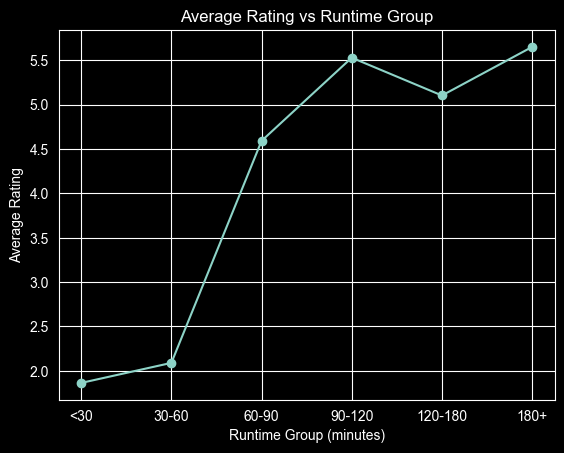

In [93]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(grouped['runtime_group'], grouped['avg_rating'], marker='o')
plt.xlabel('Runtime Group (minutes)')
plt.ylabel('Average Rating')
plt.title('Average Rating vs Runtime Group')
plt.show()

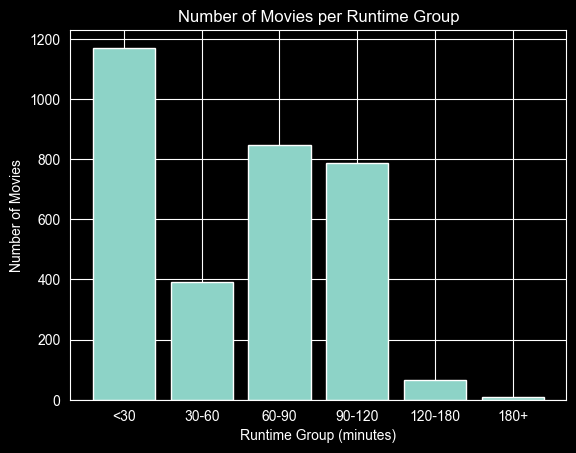

In [94]:
plt.figure()
plt.bar(grouped['runtime_group'], grouped['count'])
plt.xlabel('Runtime Group (minutes)')
plt.ylabel('Number of Movies')
plt.title('Number of Movies per Runtime Group')
plt.show()

<Axes: xlabel='runtime_group', ylabel='vote_average'>

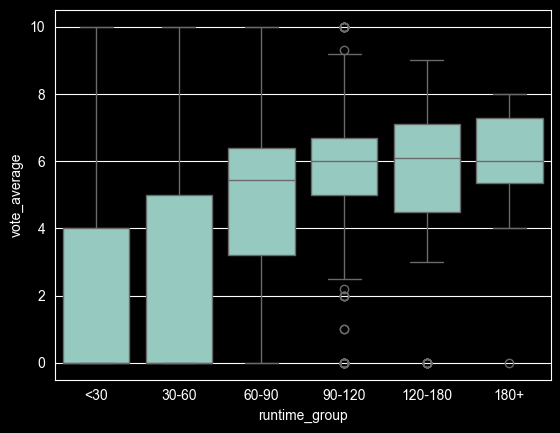

In [95]:
import seaborn as sns

sns.boxplot(x='runtime_group', y='vote_average', data=df_runtime)

In [96]:
'''
Analysis of film ratings by runtime shows a clear pattern. Very short films (<60 minutes) receive the lowest average ratings, while films in the 90–120 minute range have the highest and most consistent ratings. Although very long films (>120 minutes) sometimes show high ratings, the small sample sizes in these categories make those results less reliable. Overall, these findings support the hypothesis (H3) that films with a runtime between 90 and 120 minutestend to receive higher average ratings than very short or very long films.'''

'\nAnalysis of film ratings by runtime shows a clear pattern. Very short films (<60 minutes) receive the lowest average ratings, while films in the 90–120 minute range have the highest and most consistent ratings. Although very long films (>120 minutes) sometimes show high ratings, the small sample sizes in these categories make those results less reliable. Overall, these findings support the hypothesis (H3) that films with a runtime between 90 and 120 minutestend to receive higher average ratings than very short or very long films.'

In [97]:
(df['vote_count'] >= 10).sum()

np.int64(534)

In [98]:
for threshold in [1, 3, 5, 10]:
    count = (df['vote_count'] >= threshold).sum()
    print(f">= {threshold}: {count} films ({count/len(df)*100:.1f}%)")

>= 1: 2605 films (50.9%)
>= 3: 1393 films (27.2%)
>= 5: 984 films (19.2%)
>= 10: 534 films (10.4%)


In [99]:
df_rated = df[df['vote_count'] >= 5]

In [100]:
df[['vote_average', 'vote_count', 'runtime', 'popularity']].describe()

,vote_average,vote_count,runtime,popularity
count,5113.000000,5113.000000,3274.000000,5113.000000
mean,3.072191,10.964600,60.026878,0.620532
std,3.288898,100.547278,40.686049,0.842240
min,0.000000,0.000000,1.000000,0.000000
25%,0.000000,0.000000,20.000000,0.051600
50%,1.500000,1.000000,69.000000,0.273800
75%,6.000000,3.000000,92.000000,0.895600
max,10.000000,4472.000000,579.000000,8.813500


<Axes: >

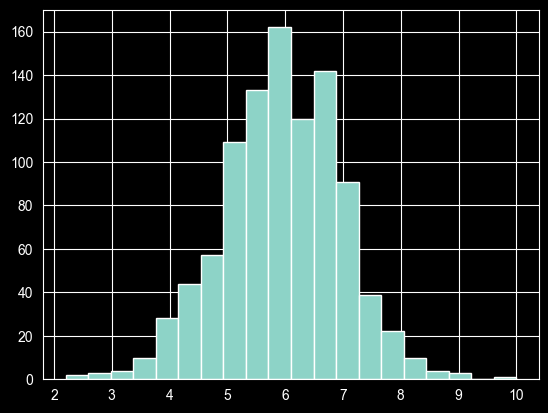

In [101]:
df_rated['vote_average'].hist(bins=20)

In [102]:
df_rated.groupby(df_rated['release_date'].dt.year)['vote_average'].mean()

release_date
1897   5.300000
1899   4.000000
1902   4.600000
1903   5.200000
1905   5.200000
         ...   
2020   6.088000
2021   6.150412
2022   6.453033
2023   6.133276
2024   6.492600
Name: vote_average, Length: 105, dtype: float64

In [106]:
print(f"Before 1950 mean rating: {before_1950.mean():.2f}")
print(f"After 1950 mean rating: {after_1950.mean():.2f}")

Before 1950 mean rating: 5.88
After 1950 mean rating: 5.95


In [107]:
''' The means are virtually identical (only 0.07 difference), which aligns perfectly with the high p-value.
Conclusion for H1:
H1 is rejected — there is no meaningful difference in ratings before and after 1950, either statistically or practically. The means are almost the same at ~5.9 for both periods.
A likely explanation is that the df_rated filter (>= 5 votes) already weeded out most of the unreliable older films, leaving only the ones that are well-known and well-regarded enough to have accumulated votes — which naturally skews older films' ratings upward.'''

" The means are virtually identical (only 0.07 difference), which aligns perfectly with the high p-value.\nConclusion for H1:\nH1 is rejected — there is no meaningful difference in ratings before and after 1950, either statistically or practically. The means are almost the same at ~5.9 for both periods.\nA likely explanation is that the df_rated filter (>= 5 votes) already weeded out most of the unreliable older films, leaving only the ones that are well-known and well-regarded enough to have accumulated votes — which naturally skews older films' ratings upward."

In [108]:
df_genre_exploded = df_genre.explode('genre_ids')

In [109]:
df_genre_exploded.groupby('genre_ids')['vote_average'].mean().sort_values(ascending=False)

genre_ids
28      5.273690
10751   5.153874
80      5.112438
10749   4.745185
14      4.713722
36      4.672333
10752   4.671785
9648    4.630167
53      4.591448
35      4.532189
37      4.296375
12      4.170048
18      3.949599
27      3.732323
16      3.093970
10402   2.809714
878     2.767729
99      2.476058
10770   2.100500
Name: vote_average, dtype: float64

In [110]:
genre_map = {
    28: "Action",
    12: "Adventure",
    16: "Animation",
    35: "Comedy",
    80: "Crime",
    99: "Documentary",
    18: "Drama",
    10751: "Family",
    14: "Fantasy",
    36: "History",
    27: "Horror",
    10402: "Music",
    9648: "Mystery",
    10749: "Romance",
    878: "Science Fiction",
    10770: "TV Movie",
    53: "Thriller",
    10752: "War",
    37: "Western"
}